In [1]:
import os

print(os.listdir('/kaggle/input/datasets/andrewmvd/animal-faces/afhq/train'))

['dog', 'wild', 'cat']


In [2]:
import torch
import matplotlib.pyplot as plot
import torchvision.transforms as transforms
import pandas as pd
import numpy as np

from torch import nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from PIL import Image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Available Device: {device}")

Available Device: cuda


In [3]:
img_path = []
labels = []

for i in os.listdir('/kaggle/input/datasets/andrewmvd/animal-faces/afhq'):
    for label in os.listdir(f'/kaggle/input/datasets/andrewmvd/animal-faces/afhq/{i}'):
        for image in os.listdir(f'/kaggle/input/datasets/andrewmvd/animal-faces/afhq/{i}/{label}'):
            img_path.append(f'/kaggle/input/datasets/andrewmvd/animal-faces/afhq/{i}/{label}/{image}')
            labels.append(label)

data_df = pd.DataFrame(zip(img_path, labels), columns=['image_path', 'labels'])
data_df

,image_path,labels
0,/kaggle/input/datasets/andrewmvd/animal-faces/...,dog
1,/kaggle/input/datasets/andrewmvd/animal-faces/...,dog
2,/kaggle/input/datasets/andrewmvd/animal-faces/...,dog
3,/kaggle/input/datasets/andrewmvd/animal-faces/...,dog
4,/kaggle/input/datasets/andrewmvd/animal-faces/...,dog
...,...,...
16125,/kaggle/input/datasets/andrewmvd/animal-faces/...,cat
16126,/kaggle/input/datasets/andrewmvd/animal-faces/...,cat
16127,/kaggle/input/datasets/andrewmvd/animal-faces/...,cat
16128,/kaggle/input/datasets/andrewmvd/animal-faces/...,cat


In [4]:
#Get the %70 of the data from original data
train = data_df.sample(frac=0.7)

#test aquire its data by droping the data of the train variable that was selected by sample of 70%, that gets 30%
test = data_df.drop(train.index)

#divide the test set into 1/2 and give it to the validation
val = test.sample(frac=0.5)

#remove the datasets selected by the random selection from  val = test.sample
test = test.drop(val.index)


In [5]:
#LabelEncoder use transform label into integer e.g wild = 0, cat = 1, dog = 2
label_encoder = LabelEncoder()

label_encoder.fit(data_df['labels'])

transform = transforms.Compose([
    #making sure that images has the same sizes
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [6]:
class CustomImageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)
        
    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image).to(device)

        return image, label

In [7]:
train_dataset = CustomImageDataset(dataframe=train, transform=transform)
val_dataset = CustomImageDataset(dataframe=val, transform=transform)
test_dataset = CustomImageDataset(dataframe=test, transform=transform)

#-----TO CONVERT THE INTEGER LABEL INTO A STRING AGAIN-----------
#label_encoder.inverse_transform([0])

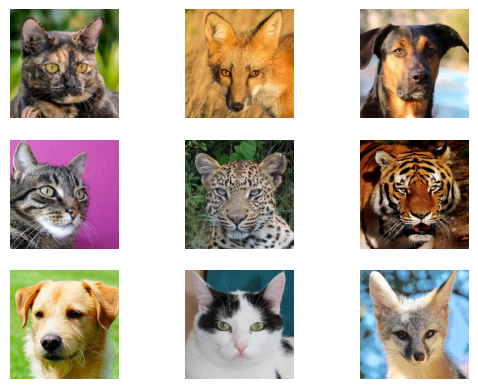

In [8]:
#Visualize images
n_rows = 3
n_cols = 3

f, axarr = plot.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col  in range(n_cols):
        image = Image.open(data_df.sample(n=1)['image_path'].iloc[0]).convert('RGB')
        axarr[row, col].imshow(image)
        axarr[row, col].axis('off')

plot.show()

In [9]:
LEARNING_RATE = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [10]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle=True)

In [11]:
class Net(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)

        self.pooling = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear =  nn.Linear((128*16*16), 128)

        self.output = nn.Linear(128, len(data_df['labels'].unique()))

    def forward(self, x):
        x = self.conv1(x) #-> (32, 128, 128)
        x = self.pooling(x) #-> (32, 64, 64)
        x = self.relu(x)

        x = self.conv2(x) # (64, 64, 64)
        x = self.pooling(x) # (64, 32 ,32)
        x = self.relu(x)

        x = self.conv3(x) #(128, 32, 32)
        x = self.pooling(x) #(128, 16, 16)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.output(x)

        return x

In [12]:
model = Net().to(device)

In [13]:
from torchsummary import summary

summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

In [15]:
#lists for plot
total_loss_train_plot = []
total_loss_val_plot = []

total_acc_train_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
    total_loss_train = 0
    total_loss_val = 0

    total_acc_train = 0
    total_acc_val = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        output = model(inputs)

        train_loss = criterion(output, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()

        train_acc = (torch.argmax(output, axis = 1) == labels).sum().item()

        total_acc_train += train_acc
        optimizer.step()

    with torch.no_grad():
        for inputs, labels in val_loader:
            
            output = model(inputs)
            val_loss = criterion(output, labels)
            total_loss_val += val_loss.item()

            val_acc =  (torch.argmax(output, axis = 1) == labels).sum().item()
            total_acc_val += val_acc
            

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_val_plot.append(round(total_loss_val/1000, 4))

    total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__() * 100, 4))
    total_acc_val_plot.append(round(total_acc_val/val_dataset.__len__() * 100, 4))

    print(f"""Epoch No. {epoch + 1} / {EPOCHS},
             Train Loss: {round(total_loss_train/1000, 4)}, Train Accuracy: {round(total_acc_train/train_dataset.__len__() * 100, 4)}
             Validation Loss: {round(total_loss_val/1000, 4)}, Validation Accuracy: {round(total_acc_val/val_dataset.__len__() * 100, 4)}
        """)
    print("="*100)

Epoch No. 1 / 10,
             Train Loss: 0.3151, Train Accuracy: 81.8439
             Validation Loss: 0.0361, Validation Accuracy: 91.1157
        
Epoch No. 2 / 10,
             Train Loss: 0.1356, Train Accuracy: 92.9147
             Validation Loss: 0.0245, Validation Accuracy: 94.1736
        
Epoch No. 3 / 10,
             Train Loss: 0.0887, Train Accuracy: 95.4123
             Validation Loss: 0.018, Validation Accuracy: 95.8264
        
Epoch No. 4 / 10,
             Train Loss: 0.0632, Train Accuracy: 96.7762
             Validation Loss: 0.0218, Validation Accuracy: 94.7934
        
Epoch No. 5 / 10,
             Train Loss: 0.0466, Train Accuracy: 97.5999
             Validation Loss: 0.0164, Validation Accuracy: 95.9917
        
Epoch No. 6 / 10,
             Train Loss: 0.0318, Train Accuracy: 98.4324
             Validation Loss: 0.0192, Validation Accuracy: 95.6612
        
Epoch No. 7 / 10,
             Train Loss: 0.0244, Train Accuracy: 98.8221
             Validat

In [16]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for inputs, labels in test_loader:

        prediction = model(inputs)
        
        acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
        total_acc_test += acc
        
        test_loss = criterion(prediction, labels)
        total_loss_test += test_loss.item()

print(f"Test Accuracy: {round(total_acc_test/test_dataset.__len__() * 100, 4)}")
print(f"Test Loss: {round(total_loss_test/1000, 4)}")

Test Accuracy: 93.8818
Test Loss: 0.0366


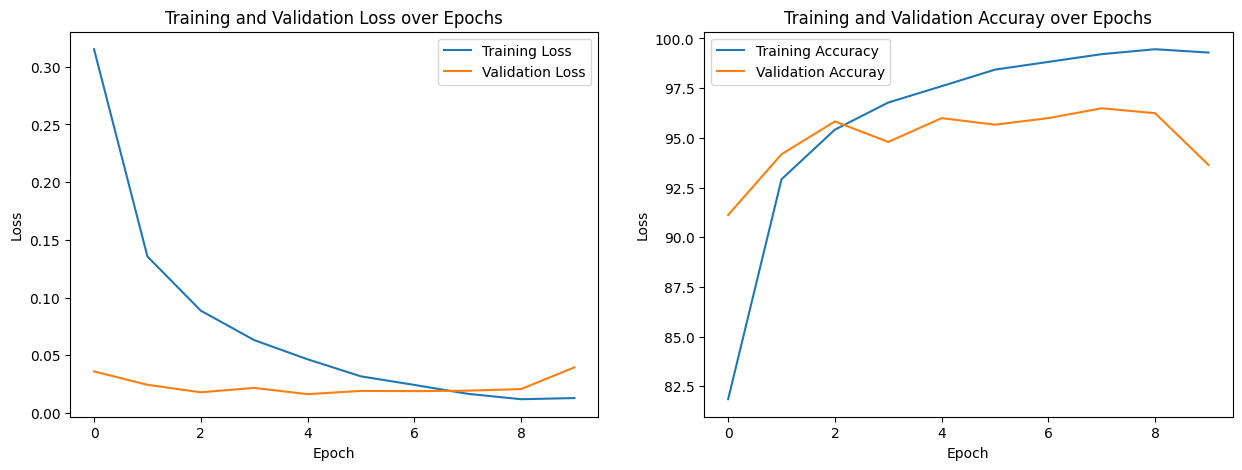

In [17]:
fig, axs = plot.subplots(nrows = 1, ncols=2, figsize=(15,5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_val_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_val_plot, label='Validation Accuray')
axs[1].set_title('Training and Validation Accuray over Epochs')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()

plot.show()

In [18]:
print(os.listdir('/kaggle/input/datasets/ronronrivera/cat-pic'))

['Cat_November_2010-1a.jpg']


In [19]:
#read image
#transform image using transform  object
#predict through the model
#inverse transform by label encoder

def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).to(device)

    print(image.shape)
    
    output = model(image.unsqueeze(0))
    output = torch.argmax(output, axis = 1).item()
    return label_encoder.inverse_transform([output])


predict_image("/kaggle/input/datasets/ronronrivera/dog-pic/dog2.jpg")

torch.Size([3, 128, 128])


array(['dog'], dtype=object)